# Imports

In [1]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch.nn as nn
from typing import List
from torch.optim import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from torch.utils.data import Dataset, random_split, DataLoader

# ELU Implementation in Python

In [2]:
def exponential_relu(x, alpha=0.01):
    return max(alpha * (np.exp(x) - 1), x)

# Globals

In [3]:
device = 'cuda'

# Dataset

In [4]:
class BostonDataset(Dataset):
    def __init__(self, csv_path):
        super().__init__()
        self.df = pd.read_csv(csv_path).dropna()
        X_df: pd.DataFrame = self.df[['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']]
        X_np = X_df.to_numpy(np.float32)
        self.X = torch.from_numpy(X_np)
        
        Y_df = self.df[['MEDV']]
        Y_np = Y_df.to_numpy(np.float32)
        self.Y = torch.from_numpy(Y_np)
        
        print(self.X.shape, self.Y.shape)
        
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]
    
    def __len__(self):
        return len(self.X)

In [5]:
dataset = BostonDataset('dataset/HousingData.csv')

torch.Size([394, 13]) torch.Size([394, 1])


# Model

In [6]:
class BostonModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(13, 26),
            nn.ReLU(),
            nn.Linear(26, 26),
            nn.ReLU(),
            nn.Linear(26, 1)
        )
        
    def forward(self, x):
        return self.model(x)

In [7]:
class ExponentialBostonModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(13, 26),
            nn.ELU(),
            nn.Linear(26, 26),
            nn.ELU(),
            nn.Linear(26, 1)
        )
        
    def forward(self, x):
        return self.model(x)

# Metrics Calculation

In [8]:
def graph_loss(train_loss_ot: List[float], val_loss_ot: List[float]):
    plt.plot(range(1, len(train_loss_ot) + 1), train_loss_ot, c='blue', label='Train Loss Over Time')
    plt.plot(range(1, len(val_loss_ot) + 1), val_loss_ot, c='red', label='Val Loss Over Time')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.grid(True)
    plt.legend()
    plt.show()

In [9]:
def calc_metrics(Y_true: torch.Tensor, Y_pred: torch.Tensor):
    Y_pred_np = Y_pred.detach().cpu().numpy()
    Y_true_np = Y_true.detach().cpu().numpy()
    
    r2 = r2_score(Y_true_np, Y_pred_np)
    
    return r2

# Inference Loop

In [10]:
def run(model_class, seed, non_train_size, epochs = 100, lr = 1e-3, print_epochs = False):
    torch.manual_seed(seed=seed)
    np.random.seed(seed=seed)

    train_dataset, test_dataset, val_dataset = random_split(dataset, [1 - non_train_size, non_train_size / 2, non_train_size / 2], generator=torch.Generator().manual_seed(seed))
    train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32)
    test_loader = DataLoader(test_dataset)
    val_loader = DataLoader(val_dataset)
    
    model = model_class().to(device)
    optimiser = Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    train_loss_ot = []
    val_loss_ot = []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", disable=not print_epochs)
        
        for inputs, targets in pbar:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimiser.zero_grad()
            outputs = model(inputs)

            loss = criterion(outputs, targets)
            loss.backward()
            optimiser.step()

            total_loss += loss.item()
            
        avg_train_loss = total_loss / len(train_loader)
        train_loss_ot.append(avg_train_loss)
        if print_epochs:
            print(f'Avg Training Loss = {avg_train_loss}')
            
        model.eval()
        total_val_loss = 0
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_val_loss += loss.item()
            
        avg_val_loss = total_val_loss / len(val_loader)
        val_loss_ot.append(avg_val_loss)
        if epoch % 10 == 0:
            print(f'Avg Validation Loss = {avg_val_loss}')
    
    model.eval()
    return train_loader, test_loader, model, train_loss_ot, val_loss_ot

In [11]:
def test(model, test_loader):
    preds = []
    targets = []

    with torch.no_grad():
        for X, Y in test_loader:
            X = X.to(device)
            preds.append(model(X).detach().cpu())
            targets.append(Y)

    Y_pred = torch.cat(preds)
    Y_true = torch.cat(targets)
    r2 = calc_metrics(Y_true, Y_pred)
    print(f'r2 score on test dataset = {r2}')

# Testing

## Seed 321, Test Size 0.3

### ReLU

Avg Validation Loss = 43.61855287631279
Avg Validation Loss = 38.70411156673553
Avg Validation Loss = 35.09667084176662
Avg Validation Loss = 30.50820040238737
Avg Validation Loss = 30.74125505933317
Avg Validation Loss = 24.336446015812434
Avg Validation Loss = 21.618007418982092
Avg Validation Loss = 20.965768830124606
Avg Validation Loss = 20.00588758578682
Avg Validation Loss = 19.212074512394807
Avg Validation Loss = 19.47126229612504
Avg Validation Loss = 18.57214457719065
Avg Validation Loss = 20.576076370300882
Avg Validation Loss = 22.487795735614657
Avg Validation Loss = 21.311013356585676
Avg Validation Loss = 16.893575027989524
Avg Validation Loss = 19.619848930292715
Avg Validation Loss = 15.686930597223089
Avg Validation Loss = 15.555563448312677
Avg Validation Loss = 16.4959492286612
Avg Validation Loss = 19.275143151913408
Avg Validation Loss = 14.56591279994128
Avg Validation Loss = 14.654997168992788
Avg Validation Loss = 13.15261804954059
Avg Validation Loss = 12.984

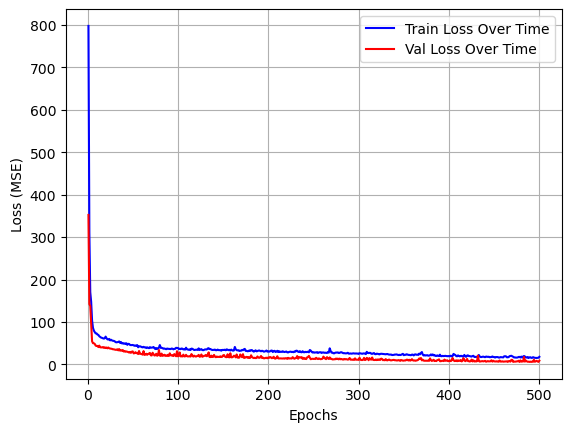

r2 score on test dataset = 0.6260415315628052


In [12]:
train_loader, test_loader, model, train_loss_ot, val_loss_ot = run(BostonModel, 321, 0.3, epochs=500, lr=1e-3)
graph_loss(train_loss_ot, val_loss_ot)
test(model, test_loader)

### ELU

Avg Validation Loss = 41.73325991403248
Avg Validation Loss = 37.993586633701696
Avg Validation Loss = 33.366253119372466
Avg Validation Loss = 29.315406800018845
Avg Validation Loss = 29.68197453653408
Avg Validation Loss = 23.623051939495657
Avg Validation Loss = 21.94810917787254
Avg Validation Loss = 21.734327153044248
Avg Validation Loss = 19.822504225948634
Avg Validation Loss = 18.64482710798571
Avg Validation Loss = 19.23417876548478
Avg Validation Loss = 18.49912772612583
Avg Validation Loss = 18.430964464763715
Avg Validation Loss = 18.55939191120866
Avg Validation Loss = 17.74133819924131
Avg Validation Loss = 15.079757511339514
Avg Validation Loss = 15.48860838017979
Avg Validation Loss = 13.541605204399538
Avg Validation Loss = 15.094659737169238
Avg Validation Loss = 13.079146329433879
Avg Validation Loss = 12.141175656355484
Avg Validation Loss = 10.642417417823385
Avg Validation Loss = 11.473669534837196
Avg Validation Loss = 9.833751981738576
Avg Validation Loss = 9.14

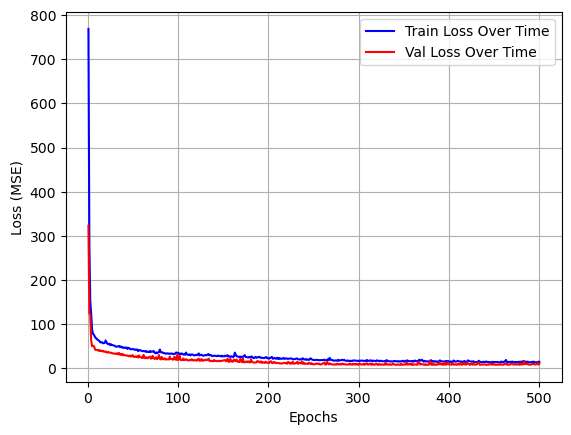

r2 score on test dataset = 0.6612230539321899


In [13]:
train_loader, test_loader, model, train_loss_ot, val_loss_ot = run(ExponentialBostonModel, 321, 0.3, epochs=500, lr=1e-3)
graph_loss(train_loss_ot, val_loss_ot)
test(model, test_loader)

## Seed 42, Test Size 0.2

### ReLU

Avg Validation Loss = 55.17789954434818
Avg Validation Loss = 52.67391666273276
Avg Validation Loss = 48.23336991288055
Avg Validation Loss = 47.62672281979571
Avg Validation Loss = 45.99231670281062
Avg Validation Loss = 44.18385744386782
Avg Validation Loss = 42.78166162017255
Avg Validation Loss = 42.14495026129178
Avg Validation Loss = 40.56524151666925
Avg Validation Loss = 37.539602112777246
Avg Validation Loss = 34.48688448134523
Avg Validation Loss = 36.29937600936645
Avg Validation Loss = 31.40164830421026
Avg Validation Loss = 30.754211153261938
Avg Validation Loss = 33.58486772901737
Avg Validation Loss = 30.049694563012917
Avg Validation Loss = 39.36478671776609
Avg Validation Loss = 33.42165105909897
Avg Validation Loss = 32.62419541027301
Avg Validation Loss = 30.20870061714847
Avg Validation Loss = 25.51611654208197
Avg Validation Loss = 26.14724421615784
Avg Validation Loss = 27.269193274422715
Avg Validation Loss = 24.726726630845896
Avg Validation Loss = 28.9852150320

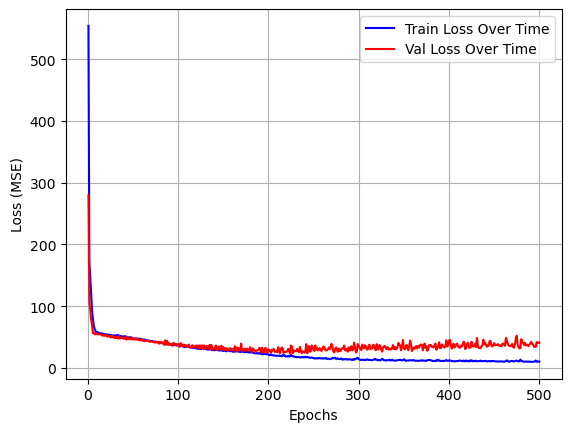

r2 score on test dataset = 0.7626174688339233


In [14]:
train_loader, test_loader, model, train_loss_ot, val_loss_ot = run(BostonModel, 42, 0.2, epochs=500, lr=1e-3)
graph_loss(train_loss_ot, val_loss_ot)
test(model, test_loader)

### ELU

Avg Validation Loss = 55.08197978267876
Avg Validation Loss = 52.11690501457988
Avg Validation Loss = 47.80495437597617
Avg Validation Loss = 46.88116258724282
Avg Validation Loss = 45.39474147118819
Avg Validation Loss = 43.633417279698335
Avg Validation Loss = 41.52028516626571
Avg Validation Loss = 41.92571581747287
Avg Validation Loss = 38.744287197215435
Avg Validation Loss = 34.1315923752502
Avg Validation Loss = 31.383308356771103
Avg Validation Loss = 32.95340601696471
Avg Validation Loss = 24.68219866662119
Avg Validation Loss = 24.760220679406746
Avg Validation Loss = 38.15354105567512
Avg Validation Loss = 24.824327963786438
Avg Validation Loss = 27.896440523760155
Avg Validation Loss = 33.200621211495346
Avg Validation Loss = 34.863252855706754
Avg Validation Loss = 27.917483639772026
Avg Validation Loss = 23.982030933141452
Avg Validation Loss = 25.85672330796623
Avg Validation Loss = 27.75542748399461
Avg Validation Loss = 25.834093003939742
Avg Validation Loss = 32.05959

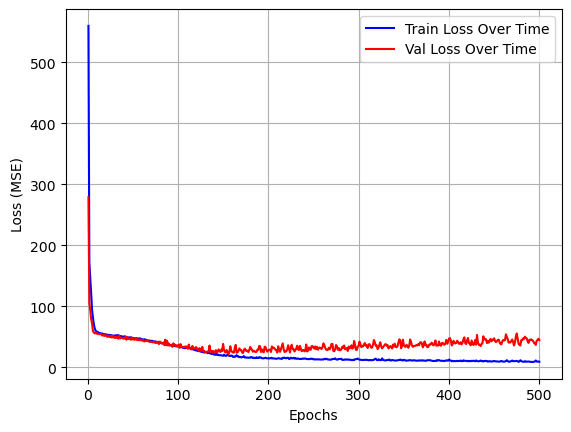

r2 score on test dataset = 0.7755160927772522


In [15]:
train_loader, test_loader, model, train_loss_ot, val_loss_ot = run(ExponentialBostonModel, 42, 0.2, epochs=500, lr=1e-3)
graph_loss(train_loss_ot, val_loss_ot)
test(model, test_loader)

## Seed 21, Test Size 0.1

### ReLU

Avg Validation Loss = 38.35620196869499
Avg Validation Loss = 27.79072847328835
Avg Validation Loss = 28.499171574649058
Avg Validation Loss = 26.003954949347598
Avg Validation Loss = 22.801827404844133
Avg Validation Loss = 22.551021860226204
Avg Validation Loss = 21.82489797080818
Avg Validation Loss = 23.370110418794578
Avg Validation Loss = 19.559637083819037
Avg Validation Loss = 15.280828452031864
Avg Validation Loss = 26.203306232824136
Avg Validation Loss = 17.163658627357922
Avg Validation Loss = 18.806899967162234
Avg Validation Loss = 19.05741520265215
Avg Validation Loss = 16.211688224201726
Avg Validation Loss = 20.450208016622224
Avg Validation Loss = 13.76820693047423
Avg Validation Loss = 12.180382619857005
Avg Validation Loss = 20.947825851948245
Avg Validation Loss = 16.918238255538437
Avg Validation Loss = 26.355491935128445
Avg Validation Loss = 19.92643930410084
Avg Validation Loss = 14.887727842764242
Avg Validation Loss = 20.305678443689096
Avg Validation Loss = 

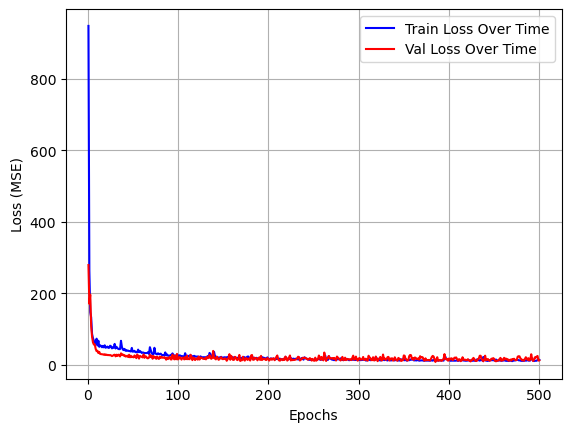

r2 score on test dataset = 0.8649988174438477


In [16]:
train_loader, test_loader, model, train_loss_ot, val_loss_ot = run(BostonModel, 21, 0.1, epochs=500, lr=1e-3)
graph_loss(train_loss_ot, val_loss_ot)
test(model, test_loader)

### ELU

Avg Validation Loss = 36.21839857375935
Avg Validation Loss = 31.969633918941806
Avg Validation Loss = 29.26342157624956
Avg Validation Loss = 27.806740310533268
Avg Validation Loss = 20.953503656054014
Avg Validation Loss = 26.572846764012386
Avg Validation Loss = 25.602432542725612
Avg Validation Loss = 14.62116541438981
Avg Validation Loss = 17.61973267009384
Avg Validation Loss = 15.584167981226193
Avg Validation Loss = 25.172318526396626
Avg Validation Loss = 13.918239135197119
Avg Validation Loss = 15.9212515063976
Avg Validation Loss = 17.55033410850324
Avg Validation Loss = 14.602579076039163
Avg Validation Loss = 28.227785608794203
Avg Validation Loss = 15.034032484418468
Avg Validation Loss = 11.52264376063096
Avg Validation Loss = 22.791377654568734
Avg Validation Loss = 13.900759840874295
Avg Validation Loss = 25.208188257033104
Avg Validation Loss = 22.232066962671908
Avg Validation Loss = 13.089099528366013
Avg Validation Loss = 24.864978508876735
Avg Validation Loss = 12

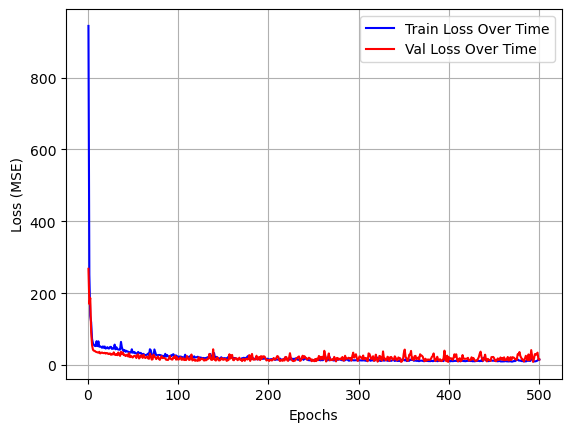

r2 score on test dataset = 0.8685554265975952


In [17]:
train_loader, test_loader, model, train_loss_ot, val_loss_ot = run(ExponentialBostonModel, 21, 0.1, epochs=500, lr=1e-3)
graph_loss(train_loss_ot, val_loss_ot)
test(model, test_loader)

# Results

| Seed  | Test Size + Val Size | ReLU Used | R2 Score  |
|-------|----------------------|-----------|-----------|
|321    | 0.3                  | Normal    | 0.626     |
|321    | 0.3                  | Exp       | 0.661     |
|42     | 0.2                  | Normal    | 0.762     |
|42     | 0.2                  | Exp       | 0.775     |
|21     | 0.1                  | Normal    | 0.864     |
|21     | 0.1                  | Exp       | 0.868     |

ELU seems to perform better than ReLU by a marginal amount.